<a href="https://colab.research.google.com/github/shannigrahiayan36-dot/cifar10/blob/main/cifar10batchnormalisation%2Bselu%2Balphadropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification with Deep Neural Networks

This notebook demonstrates a deep learning approach to classifying images from the CIFAR-10 dataset using TensorFlow and Keras. The project covers data preprocessing, scaling, and training a deep MLP with modern optimization techniques like the Nadam optimizer.

In [2]:
import numpy, pandas, matplotlib

## 1. Model Architecture

We define a Sequential model optimized for **Self-Normalization**. We use the **SELU** activation function combined with **LeCun Normal** initialization. This configuration allows the network to maintain a mean of 0 and standard deviation of 1 across layers, provided the input features are standardized. We use multiple Dense layers followed by AlphaDropout to preserve the self-normalizing property.

In [3]:
from tensorflow import keras

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[32, 32, 3]),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.1),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 2. Data Loading and Preprocessing

We load the CIFAR-10 dataset and standardize the pixel values. Instead of simple min-max scaling, we calculate the mean and standard deviation of the training set to shift the distribution to have a mean of 0 and a standard deviation of 1. This is specifically required for the **SELU** activation function to ensure the network remains self-normalizing.

In [4]:
Data=keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 111s 1us/step


In [7]:
import numpy as np

(X_train_full, y_train_full), (X_test, y_test) = Data

# Standardize for self-normalization (mean 0, std 1)
# Instead of simple 0-1 scaling, we use the mean and std of the training set
mean = X_train_full.mean(axis=0)
std = X_train_full.std(axis=0)

X_train_full = (X_train_full - mean) / std
X_test = (X_test - mean) / std

print(f"Standardized X_train_full shape: {X_train_full.shape}")

Standardized X_train_full shape: (50000, 32, 32, 3)


In [8]:
# Creating validation set
# Pixel values are normalized [0, 1] in the previous step.
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print(f"Validation set shape: {X_valid.shape}")
print(f"New training set shape: {X_train.shape}")

Validation set shape: (5000, 32, 32, 3)
New training set shape: (45000, 32, 32, 3)


### Data Visualization

Visualizing a sample image from the training set confirms the data is loaded correctly. Note that because the data is standardized (containing negative values and values > 1), matplotlib will clip the values when displaying. This is expected behavior for standardized image data.

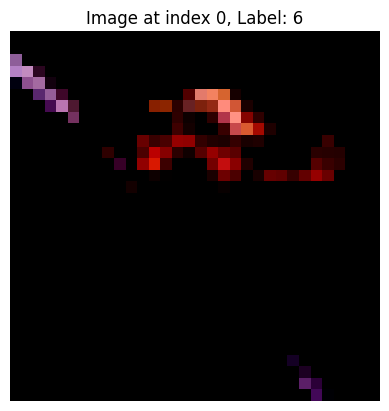

In [9]:
import matplotlib.pyplot as plt

#loding a image
first_image = X_train[0]
first_label = y_train[0]

# Display the image
plt.imshow(first_image)
plt.title(f"Image at index {0}, Label: {first_label[0]}")
plt.axis('off') # Hide axes for a cleaner look
plt.show()

## 3. Optimization and Training

We use the **Nadam** optimizer, which combines Nag (Nesterov Accelerated Gradient) with Adam, for faster convergence. We also implement **Early Stopping** to monitor the validation loss and restore the best weights if the model stops improving, effectively preventing overfitting.

In [10]:
optimizer = keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [11]:
import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
)

In [12]:
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), callbacks=[early_stopping], epochs=100)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.2841 - loss: 2.0050 - val_accuracy: 0.3806 - val_loss: 2.1780
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3687 - loss: 1.7648 - val_accuracy: 0.3946 - val_loss: 2.5102
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4042 - loss: 1.6825 - val_accuracy: 0.4270 - val_loss: 2.5965
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4257 - loss: 1.6256 - val_accuracy: 0.4342 - val_loss: 2.6343
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4381 - loss: 1.5950 - val_accuracy: 0.4510 - val_loss: 2.6098
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4465 - loss: 1.5637 - val_accuracy: 0.4394 - val_loss: 2.2975
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4604 - loss: 1.5380 - val_accuracy: 0.4670 - val_loss: 2.7723
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 

## 4. Performance Evaluation

We analyze the learning curves. The gap between training and validation metrics helps identify if the model is overfitting or if further regularization/architecture changes are needed.

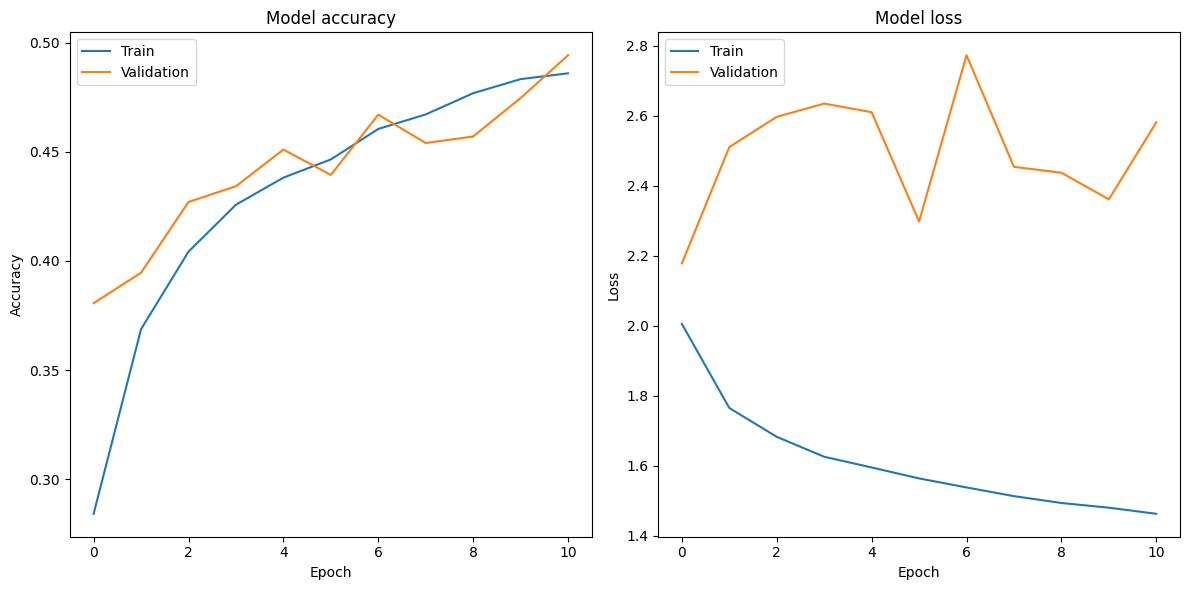

In [13]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
B

NameError: name 'B' is not defined